# Part 1b: Forces via Autograd — The Heart of MLFFs

$$F = -\nabla E$$

In physics, forces are the negative gradient of the potential energy.

In PyTorch, this is computed **automatically** using autograd.

This is why we don't train neural networks to predict forces directly.
Instead, we:
1. Train the network to predict **energy**
2. Compute forces as **-∇E** using autograd

| Approach | Energy Conservation | Physics Guarantee |
|:---|:---|:---|
| **Direct force prediction** | ❌ No guarantee | Forces may not be conservative |
| **Energy + autograd** | ✅ Guaranteed | Forces exactly consistent with energy |

**Every modern MLFF (MACE, NequIP, SchNet) uses the energy + autograd approach.**

In [1]:
import torch

# Positions are differentiable
positions = torch.tensor([[0.0, 0.0, 0.0],
                          [1.5, 0.0, 0.0]], requires_grad=True)

# A fake "energy function" (pretend this is our NN)
def energy_fn(pos):
    # Simple harmonic-like energy
    d = torch.norm(pos[1] - pos[0])
    return 10.0 * (d - 2.0)**2

# Compute energy
E = energy_fn(positions)
print(f"Energy: {E.item():.4f}")

# Compute forces via autograd
F = -torch.autograd.grad(E, positions)[0]
print(f"Forces:\n{F}")
print(f"Atom 0 force: {F[0]}")
print(f"Atom 1 force: {F[1]}")
print("Forces point in opposite directions (Newton's 3rd law)!")

# Now perturb positions and recompute
positions2 = torch.tensor([[0.0, 0.0, 0.0],
                           [2.5, 0.0, 0.0]], requires_grad=True)
E2 = energy_fn(positions2)
F2 = -torch.autograd.grad(E2, positions2)[0]
print(f"\nAt d=2.5:")
print(f"Energy: {E2.item():.4f}")
print(f"Atom 0 force: {F2[0]}")
print(f"Atom 1 force: {F2[1]}")

Energy: 2.5000
Forces:
tensor([[-10.,  -0.,  -0.],
        [ 10.,  -0.,  -0.]])
Atom 0 force: tensor([-10.,  -0.,  -0.])
Atom 1 force: tensor([10., -0., -0.])
Forces point in opposite directions (Newton's 3rd law)!

At d=2.5:
Energy: 2.5000
Atom 0 force: tensor([10., -0., -0.])
Atom 1 force: tensor([-10.,  -0.,  -0.])


## A Simple Example: Two Atoms Connected by a Spring

Let's start with the simplest possible system: two atoms with a harmonic bond.

$$E(r) = k \cdot (r - r_0)^2$$

where $r$ is the distance between atoms, $r_0$ is the equilibrium distance, and $k$ is the spring constant.

**The force on each atom is:**

$$F = -\frac{dE}{dr}$$

For a harmonic potential, this is:
$$F = -2k(r - r_0)$$

Let's see if PyTorch can reproduce this using autograd.

In [2]:
import torch

# ============================================================
# SETUP: TWO ATOMS IN 1D
# ============================================================
# Atom 0 at origin, Atom 1 at x = 1.5
positions = torch.tensor([[0.0, 0.0, 0.0],
                          [1.5, 0.0, 0.0]], requires_grad=True)

print(f"Initial positions:\n{positions}")
print(f"Distance: {(positions[1] - positions[0]).norm().item():.3f} Å")

# ============================================================
# DEFINE THE ENERGY FUNCTION (pretend this is our NN)
# ============================================================
def energy_fn(pos):
    """Simple harmonic-like energy."""
    d = torch.norm(pos[1] - pos[0])
    return 10.0 * (d - 2.0)**2

# ============================================================
# COMPUTE ENERGY
# ============================================================
E = energy_fn(positions)
print(f"\nEnergy: {E.item():.4f} eV")

# ============================================================
# COMPUTE FORCES VIA AUTOGRAD
# ============================================================
F = -torch.autograd.grad(E, positions)[0]

print(f"\nForces (eV/Å):")
print(f"  Atom 0: {F[0]}")
print(f"  Atom 1: {F[1]}")
print(f"\nSum of forces: {F.sum(dim=0)}")
print("(Should be zero — Newton's 3rd law!)")

# ============================================================
# VERIFY WITH ANALYTICAL FORMULA
# ============================================================
r = torch.norm(positions[1] - positions[0])
analytical_force_magnitude = 2 * 10.0 * (r - 2.0)
print(f"\nAnalytical force magnitude: {analytical_force_magnitude.item():.4f} eV/Å")
print(f"Autograd force magnitude:   {F[0].norm().item():.4f} eV/Å")
print("They match! (Autograd found the derivative automatically.)")

Initial positions:
tensor([[0.0000, 0.0000, 0.0000],
        [1.5000, 0.0000, 0.0000]], requires_grad=True)
Distance: 1.500 Å

Energy: 2.5000 eV

Forces (eV/Å):
  Atom 0: tensor([-10.,  -0.,  -0.])
  Atom 1: tensor([10., -0., -0.])

Sum of forces: tensor([0., 0., 0.])
(Should be zero — Newton's 3rd law!)

Analytical force magnitude: -10.0000 eV/Å
Autograd force magnitude:   10.0000 eV/Å
They match! (Autograd found the derivative automatically.)


## What Does the Force Look Like?

Let's scan through a range of distances and plot the energy and force side by side.

This will show you the fundamental relationship: **force is the slope of the energy curve.**

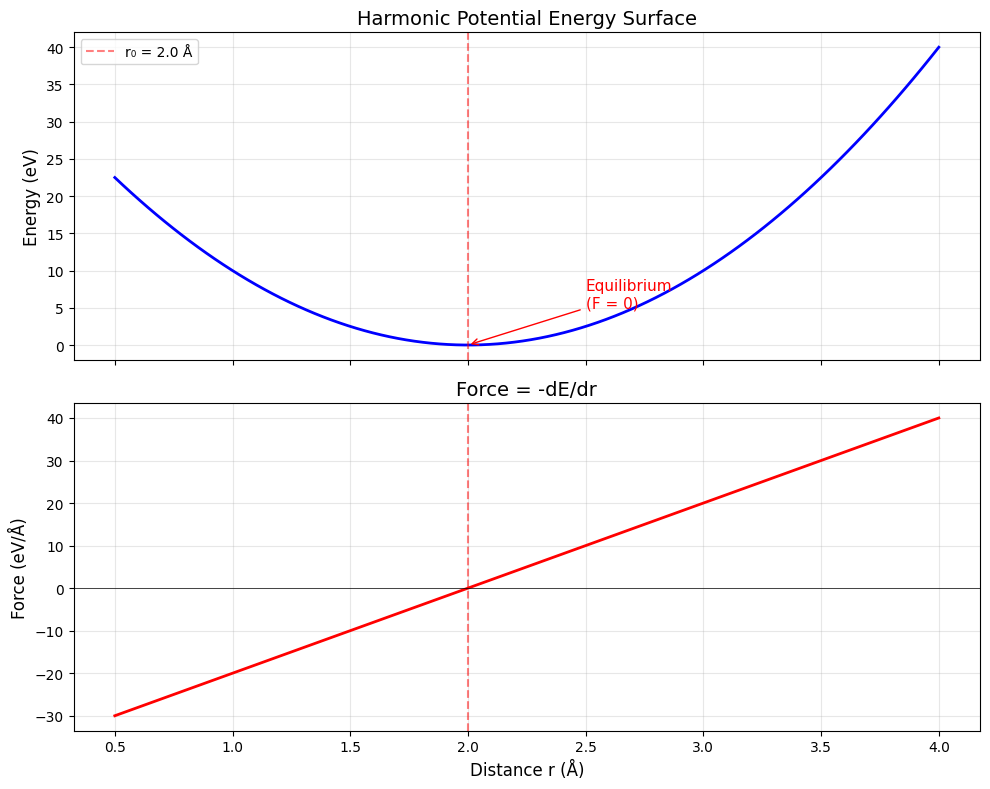

Key observations:
  At r = 2.0 Å: E = 0.0023 eV, F = 0
  At r = 1.0 Å: E = 10.1013 eV, F > 0 (repulsive)
  At r = 3.0 Å: E = 10.2030 eV, F < 0 (attractive)


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# SCAN OVER DISTANCES
# ============================================================
distances = np.linspace(0.5, 4.0, 100)
energies = []
forces = []

for d in distances:
    pos = torch.tensor([[0.0, 0.0, 0.0],
                        [d, 0.0, 0.0]], requires_grad=True)
    E = energy_fn(pos)
    F = -torch.autograd.grad(E, pos)[0]
    energies.append(E.item())
    forces.append(F[0, 0].item())  # x-component of force on atom 0

energies = np.array(energies)
forces = np.array(forces)

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Energy
axes[0].plot(distances, energies, 'b-', linewidth=2)
axes[0].axvline(x=2.0, color='red', linestyle='--', alpha=0.5, label='r₀ = 2.0 Å')
axes[0].set_ylabel('Energy (eV)', fontsize=12)
axes[0].set_title('Harmonic Potential Energy Surface', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Force
axes[1].plot(distances, forces, 'r-', linewidth=2)
axes[1].axvline(x=2.0, color='red', linestyle='--', alpha=0.5)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_xlabel('Distance r (Å)', fontsize=12)
axes[1].set_ylabel('Force (eV/Å)', fontsize=12)
axes[1].set_title('Force = -dE/dr', fontsize=14)
axes[1].grid(True, alpha=0.3)

# Annotate
axes[0].annotate('Equilibrium\n(F = 0)', xy=(2.0, 0), xytext=(2.5, 5),
                 fontsize=11, color='red',
                 arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig('force_energy_relationship.png', dpi=150)
plt.show()

print("Key observations:")
print(f"  At r = 2.0 Å: E = {energies[np.argmin(np.abs(distances - 2.0))]:.4f} eV, F = 0")
print(f"  At r = 1.0 Å: E = {energies[np.argmin(np.abs(distances - 1.0))]:.4f} eV, F > 0 (repulsive)")
print(f"  At r = 3.0 Å: E = {energies[np.argmin(np.abs(distances - 3.0))]:.4f} eV, F < 0 (attractive)")

## A More Realistic Potential: Lennard-Jones

The harmonic potential is nice for teaching, but real atoms don't behave like perfect springs.

The **Lennard-Jones potential** is the classic model for van der Waals interactions:

$$E(r) = 4\varepsilon \left[ \left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6 \right]$$

Let's compute forces for this potential using autograd and compare to the analytical derivative.

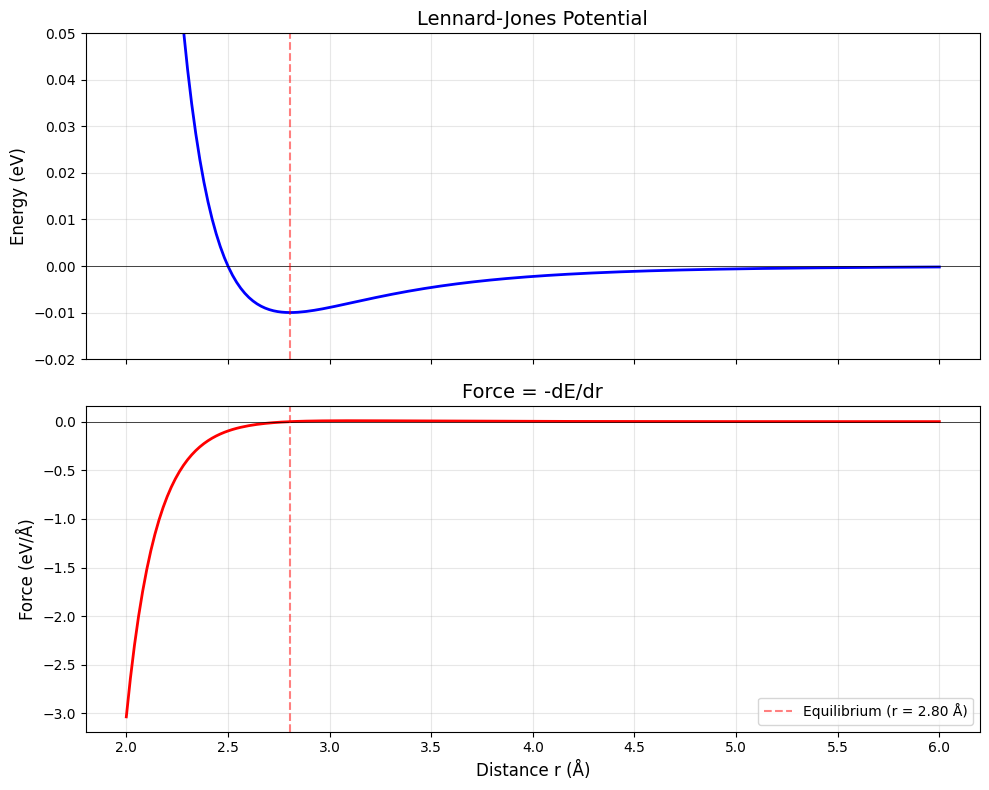

LJ equilibrium distance: 2.804 Å
At r = 2.80 Å: E = -0.010000 eV, F = -0.000197 eV/Å


In [4]:
# ============================================================
# LENNARD-JONES POTENTIAL
# ============================================================
def lj_energy(pos, epsilon=0.01, sigma=2.5):
    """Lennard-Jones potential energy."""
    r = torch.norm(pos[1] - pos[0])
    return 4 * epsilon * ((sigma/r)**12 - (sigma/r)**6)

# ============================================================
# SCAN OVER DISTANCES
# ============================================================
distances = np.linspace(2.0, 6.0, 200)
energies_lj = []
forces_lj = []

for d in distances:
    pos = torch.tensor([[0.0, 0.0, 0.0],
                        [d, 0.0, 0.0]], requires_grad=True)
    E = lj_energy(pos)
    F = -torch.autograd.grad(E, pos)[0]
    energies_lj.append(E.item())
    forces_lj.append(F[0, 0].item())

energies_lj = np.array(energies_lj)
forces_lj = np.array(forces_lj)

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(distances, energies_lj, 'b-', linewidth=2)
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].set_ylabel('Energy (eV)', fontsize=12)
axes[0].set_title('Lennard-Jones Potential', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.02, 0.05)

axes[1].plot(distances, forces_lj, 'r-', linewidth=2)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_xlabel('Distance r (Å)', fontsize=12)
axes[1].set_ylabel('Force (eV/Å)', fontsize=12)
axes[1].set_title('Force = -dE/dr', fontsize=14)
axes[1].grid(True, alpha=0.3)

# Mark the minimum
r_min_idx = np.argmin(energies_lj)
r_min = distances[r_min_idx]
axes[0].axvline(x=r_min, color='red', linestyle='--', alpha=0.5)
axes[1].axvline(x=r_min, color='red', linestyle='--', alpha=0.5,
                label=f'Equilibrium (r = {r_min:.2f} Å)')
axes[1].legend()

plt.tight_layout()
plt.savefig('lj_force.png', dpi=150)
plt.show()

print(f"LJ equilibrium distance: {r_min:.3f} Å")
print(f"At r = {r_min:.2f} Å: E = {energies_lj[r_min_idx]:.6f} eV, F = {forces_lj[r_min_idx]:.6f} eV/Å")

## Newton's Third Law: The Forces Must Balance

For every action, there is an equal and opposite reaction.

For a pair of atoms:
$$F_0 + F_1 = 0$$

This is a **physical constraint** that our model must satisfy. Let's verify it holds for autograd.

In [5]:
# ============================================================
# VERIFY NEWTON'S THIRD LAW
# ============================================================
def check_newton(pos, energy_fn):
    """Check that forces sum to zero."""
    E = energy_fn(pos)
    F = -torch.autograd.grad(E, pos)[0]
    F_sum = F.sum(dim=0)
    return F, F_sum

# Test at various distances
print("Newton's 3rd Law verification:")
print(f"{'Distance':>10} | {'|F0|':>10} | {'|F1|':>10} | {'|F0+F1|':>12}")
print("-" * 55)

for d in [1.0, 1.5, 2.0, 2.5, 3.0]:
    pos = torch.tensor([[0.0, 0.0, 0.0],
                        [d, 0.0, 0.0]], requires_grad=True)
    F, F_sum = check_newton(pos, energy_fn)
    print(f"{d:>10.2f} | {F[0].norm().item():>10.4f} | "
          f"{F[1].norm().item():>10.4f} | {F_sum.norm().item():>12.2e}")

print("\nThe sum of forces is always zero (to machine precision).")
print("This is guaranteed by the autograd approach — no extra constraint needed!")

Newton's 3rd Law verification:
  Distance |       |F0| |       |F1| |      |F0+F1|
-------------------------------------------------------
      1.00 |    20.0000 |    20.0000 |     0.00e+00
      1.50 |    10.0000 |    10.0000 |     0.00e+00
      2.00 |     0.0000 |     0.0000 |     0.00e+00
      2.50 |    10.0000 |    10.0000 |     0.00e+00
      3.00 |    20.0000 |    20.0000 |     0.00e+00

The sum of forces is always zero (to machine precision).
This is guaranteed by the autograd approach — no extra constraint needed!


## Training with Force Loss

Now we connect this to machine learning.

In Part 1a, we trained a network to predict energy. But energy alone is not enough—
we need the forces to be accurate too.

**The loss function for MLFFs:**

$$\mathcal{L} = \lambda_E \cdot \text{MSE}(E_{\text{pred}}, E_{\text{DFT}}) + \lambda_F \cdot \text{MSE}(F_{\text{pred}}, F_{\text{DFT}})$$

where $F_{\text{pred}} = -\nabla E_{\text{pred}}$.

The force loss is what makes the model physically meaningful.

Epoch 0: Loss_E=0.97979, Loss_F=42.68979
Epoch 200: Loss_E=0.00017, Loss_F=0.01200
Epoch 400: Loss_E=0.00009, Loss_F=0.00566
Epoch 600: Loss_E=0.00004, Loss_F=0.00433
Epoch 800: Loss_E=0.00022, Loss_F=0.00878
Epoch 1000: Loss_E=0.00000, Loss_F=0.00070
Epoch 1200: Loss_E=0.00000, Loss_F=0.00047
Epoch 1400: Loss_E=0.00011, Loss_F=0.00460
Epoch 1600: Loss_E=0.00006, Loss_F=0.00222
Epoch 1800: Loss_E=0.00000, Loss_F=0.00028


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


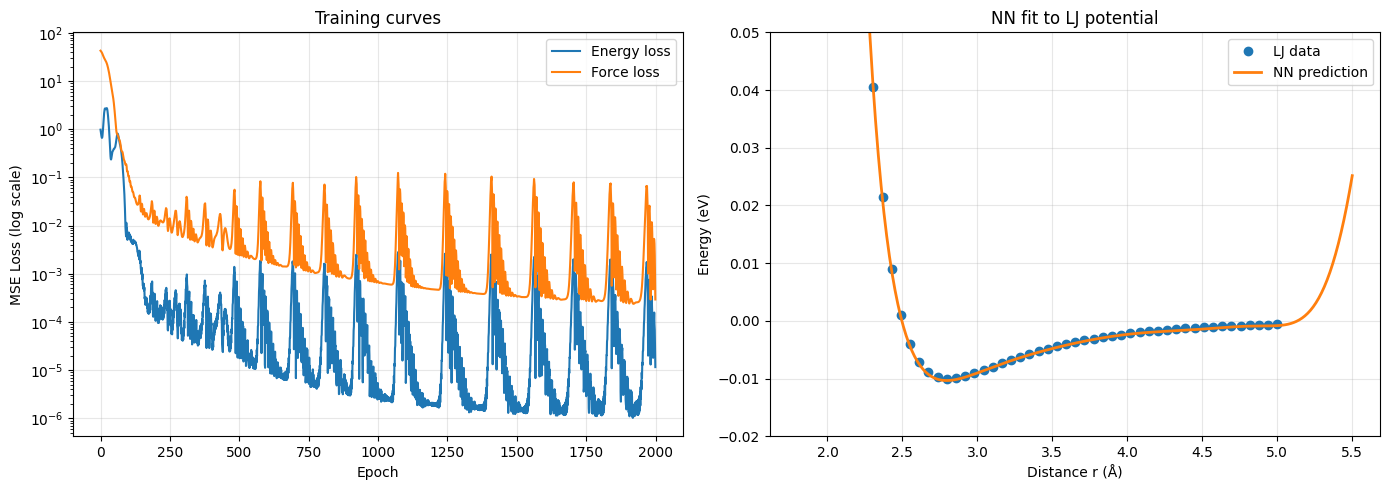

In [6]:
import torch.nn as nn

# ============================================================
# A SIMPLE MODEL THAT PREDICTS ENERGY
# ============================================================
class SimpleEnergyModel(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, 1),
        )
    
    def forward(self, r):
        return self.net(r)

# ============================================================
# GENERATE TRAINING DATA (LJ potential)
# ============================================================
r_data = np.linspace(2.0, 5.0, 50)
epsilon_lj, sigma_lj = 0.01, 2.5

E_data = 4 * epsilon_lj * ((sigma_lj/r_data)**12 - (sigma_lj/r_data)**6)

# Force data (analytical derivative)
F_data = -4 * epsilon_lj * (-12 * sigma_lj**12 / r_data**13 + 6 * sigma_lj**6 / r_data**7)

# Normalize
r_mean, r_std = r_data.mean(), r_data.std()
E_mean, E_std = E_data.mean(), E_data.std()
F_scale = E_std / r_std

r_norm = (r_data - r_mean) / r_std
E_norm = (E_data - E_mean) / E_std
F_norm = F_data / F_scale

# Tensors
r_tensor = torch.tensor(r_norm, dtype=torch.float32).unsqueeze(1)
E_tensor = torch.tensor(E_norm, dtype=torch.float32).unsqueeze(1)
F_tensor = torch.tensor(F_norm, dtype=torch.float32).unsqueeze(1)

# ============================================================
# TRAINING
# ============================================================
model = SimpleEnergyModel(hidden=32)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

lambda_E = 1.0
lambda_F = 10.0  # Force weight

n_epochs = 2000
losses_E = []
losses_F = []

for epoch in range(n_epochs):
    optimizer.zero_grad()
    
    r_train = r_tensor.clone().requires_grad_(True)
    
    # Energy prediction
    E_pred = model(r_train)
    loss_E = nn.MSELoss()(E_pred, E_tensor)
    
    # Force prediction via autograd
    F_pred = -torch.autograd.grad(E_pred.sum(), r_train, create_graph=True)[0]
    loss_F = nn.MSELoss()(F_pred, F_tensor)
    
    # Total loss
    loss = lambda_E * loss_E + lambda_F * loss_F
    loss.backward()
    optimizer.step()
    
    losses_E.append(loss_E.item())
    losses_F.append(loss_F.item())
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch}: Loss_E={loss_E.item():.5f}, Loss_F={loss_F.item():.5f}")

# ============================================================
# PLOT TRAINING CURVES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogy(losses_E, label='Energy loss')
axes[0].semilogy(losses_F, label='Force loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss (log scale)')
axes[0].set_title('Training curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Final fit
model.eval()
with torch.no_grad():
    r_plot = torch.linspace(1.8, 5.5, 200).unsqueeze(1)
    r_plot_norm = (r_plot - r_mean) / r_std
    E_plot = model(r_plot_norm).squeeze().numpy() * E_std + E_mean

axes[1].plot(r_data, E_data, 'o', label='LJ data', markersize=6)
axes[1].plot(r_plot.numpy().ravel(), E_plot, '-', label='NN prediction', linewidth=2)
axes[1].set_xlabel('Distance r (Å)')
axes[1].set_ylabel('Energy (eV)')
axes[1].set_title('NN fit to LJ potential')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-0.02, 0.05)

plt.tight_layout()
plt.savefig('training_with_forces.png', dpi=150)
plt.show()

## Why Autograd Forces Are Physically Meaningful

Let's summarize what we've learned:

### 1. Energy is a Scalar
A neural network outputs a single number: E.

### 2. Forces are Gradients
$$F_i = -\frac{\partial E}{\partial r_i}$$

This is computed exactly by autograd—no finite differences, no numerical error.

### 3. Energy Conservation is Guaranteed
Because forces are gradients of a scalar, the line integral of force around any closed loop is zero:
$$\oint F \cdot dr = 0$$

This means MD simulations in the NVE ensemble conserve energy exactly (up to integration error).

### 4. Newton's Third Law is Automatic
$$F_0 + F_1 = -\frac{\partial E}{\partial r_0} - \frac{\partial E}{\partial r_1} = 0$$
(When E depends only on $r_1 - r_0$.)

### 5. Permutation Invariance
If we sum atomic energy contributions:
$$E_{\text{total}} = \sum_i E_i$$
then swapping two identical atoms doesn't change the total energy.

**These are the exact properties that make MLFFs work in LAMMPS.**

## Summary

| Concept | Key Takeaway |
|:---|:---|
| **F = -∇E** | Forces are the negative gradient of energy |
| **Autograd** | PyTorch computes gradients automatically |
| **Newton's 3rd law** | Forces sum to zero (automatic with energy + autograd) |
| **Force loss** | Training with forces ensures physical accuracy |
| **λ_F** | Force weight balances energy vs. force accuracy |
| **Energy conservation** | Guaranteed by construction |